# GoPay Google Play Review - Data Preprocessing

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `03 - Preprocessing`

This notebook continues from the review scraping process covered in [2-Gopay-Review-EDA.ipynb](https://colab.research.google.com/drive/1ISGrXpD_I_7GDQQrEpuJN9NpGXTNxeCw?usp=sharing)

---

## Objective

This notebook transforms the raw GoPay review data (from notebook 02 — EDA) into a clean, analysis-ready dataset for sentiment analysis and TF-IDF extraction.

## Preprocessing Pipeline

The preprocessing steps are ordered intentionally — each step depends on the output of the previous one:

| Step | Task | Tool / Source |
|------|------|---------------|
| 1 | Drop unnecessary columns | pandas |
| 2 | Handle missing & empty values | pandas |
| 3 | Remove duplicates | pandas |
| 4 | Sentiment labeling | rule-based (score mapping) |
| 5 | Case folding | `.str.lower()` |
| 6 | Slang normalization | **kamus-alay** — 5,700 entry Indonesian slang corpus (Salsabila et al., 2018) |
| 7 | Text cleaning | `re`, `emoji` |
| 8 | Spelling correction | **`autocorrect`** Indonesian statistical model |
| 9 | Tokenization | **NLTK** `word_tokenize` |
| 10 | Stopword removal | **NLTK** Indonesian (758 words) + Sastrawi + domain custom |
| 11 | Frequent words analysis (n=50/100/1000) | `Counter` — iterative feedback to step 10 |
| 12 | Lemmatization | **`nlp-id`** (Kumparan) — trained Indonesian lemmatizer |
| 13 | Stemming | **PySastrawi** (ECS algorithm) |
| 14 | Rare words removal | corpus frequency threshold |
| 15 | Common words removal | document frequency threshold |
| 16 | Reconstruct text & save `cleandata.csv` | pandas |

## 1. Setup & Installation

In [1]:
!pip install Sastrawi -q
!pip install emoji -q
!pip install autocorrect -q

# nlp-id: Kumparan's Indonesian NLP library
!pip install nlp-id -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('Installation complete.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.34.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.
mlxtend 0.24.0 requires scipy>=1.16.3, but you have scipy 1.15.3 whic

Installation complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import urllib.request
import emoji
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# nlp-id: Indonesian NLP by Kumparan
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.stopword import StopWord

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from autocorrect import Speller

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
df = pd.read_csv('gopay_reviews_raw.csv')
print(f'Shape: {df.shape}')
df.info()

Shape: (367195, 11)
<class 'pandas.DataFrame'>
RangeIndex: 367195 entries, 0 to 367194
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              367195 non-null  str  
 1   userName              367195 non-null  str  
 2   userImage             367195 non-null  str  
 3   content               367194 non-null  str  
 4   score                 367195 non-null  int64
 5   thumbsUpCount         367195 non-null  int64
 6   reviewCreatedVersion  306103 non-null  str  
 7   at                    367195 non-null  str  
 8   replyContent          61660 non-null   str  
 9   repliedAt             61660 non-null   str  
 10  appVersion            306103 non-null  str  
dtypes: int64(2), str(9)
memory usage: 135.5 MB


## 3. Drop Unnecessary Columns

For sentiment analysis we only need: `content`, `score`, `at`, `thumbsUpCount`, `replyContent`.

In [5]:
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']
df = df.drop(columns=cols_to_drop)
print(f'Dropped: {cols_to_drop}')
print(f'Remaining: {df.columns.tolist()}')
df.head(3)

Dropped: ['reviewId', 'userName', 'userImage', 'appVersion']
Remaining: ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54
1,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN
2,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN


## 4. Handle Missing & Empty Values

In [6]:
rows_before = len(df)
df = df.dropna(subset=['content'])
df = df[df['content'].str.strip() != '']
print(f'Removed {rows_before - len(df):,} rows | Remaining: {len(df):,}')

Removed 1 rows | Remaining: 367,194


## 5. Remove Duplicate Reviews

In [7]:
rows_before = len(df)
df = df.drop_duplicates(subset='content', keep='first')
print(f'Duplicates removed: {rows_before - len(df):,} | Remaining: {len(df):,}')

Duplicates removed: 148,550 | Remaining: 218,644


## 6. Sentiment Labeling

| Score | Label |
|-------|-------|
| 1–2   | negative |
| 3     | neutral |
| 4–5   | positive |

In [8]:
def label_sentiment(score):
    if score <= 2:   return 'negative'
    elif score == 3: return 'neutral'
    else:            return 'positive'

df['sentiment'] = df['score'].apply(label_sentiment)
print(df['sentiment'].value_counts())
print(f'\nDistribusi (%):')
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))

sentiment
positive    149295
negative     59804
neutral       9545
Name: count, dtype: int64

Distribusi (%):
sentiment
positive    68.28
negative    27.35
neutral      4.37
Name: proportion, dtype: float64


## 7. Case Folding

Must be done **first** — normalizes text before any dictionary lookup or pattern matching.

In [9]:
df['cleaned'] = df['content'].astype(str).str.lower()
df[['content', 'cleaned']].head(3)

,content,cleaned
0,"Baru kali ini pakai gopay kek gini, tadi saya ...","baru kali ini pakai gopay kek gini, tadi saya ..."
1,busuk,busuk
2,selalu dapat bonus,selalu dapat bonus


## 8. Slang Normalization

Using the **colloquial-indonesian-lexicon** (Salsabila et al., 2018) — a published NLP
research corpus with ~5,700 Indonesian informal word mappings, sourced from Twitter/social media.

> Repository: https://github.com/nasalsabila/kamus-alay

This replaces any manual dictionary. The corpus covers abbreviations, typo-slang,
and informal contractions common in Indonesian app reviews.

In [10]:
SLANG_URL = ('https://raw.githubusercontent.com/nasalsabila/'
             'kamus-alay/master/colloquial-indonesian-lexicon.csv')

try:
    urllib.request.urlretrieve(SLANG_URL, 'colloquial-indonesian-lexicon.csv')
    slang_df  = pd.read_csv('colloquial-indonesian-lexicon.csv')
    slang_dict = dict(zip(slang_df['slang'].str.lower(),
                          slang_df['formal'].str.lower()))
    print(f'kamus-alay loaded: {len(slang_dict):,} entries')
    print('Sample:')
    for k, v in list(slang_dict.items())[:8]:
        print(f'  {k:<15} -> {v}')
except Exception as e:
    print(f'Download failed ({e}) — using minimal fallback.')
    slang_dict = {
        'gak':'tidak','ga':'tidak','gk':'tidak','nggak':'tidak',
        'yg':'yang','tp':'tapi','utk':'untuk','dgn':'dengan',
        'udh':'sudah','udah':'sudah','blm':'belum','lg':'lagi',
        'bs':'bisa','jg':'juga','aja':'saja','dr':'dari',
        'krn':'karena','bgt':'banget','emg':'memang','jd':'jadi',
        'skrg':'sekarang','msh':'masih','sy':'saya','gw':'saya',
        'apk':'aplikasi','app':'aplikasi',
    }
    print(f'Fallback: {len(slang_dict)} entries')

kamus-alay loaded: 4,331 entries
Sample:
  woww            -> wow
  aminn           -> amin
  met             -> selamat
  netaas          -> menetas
  keberpa         -> keberapa
  eeeehhhh        -> eh
  kata2nyaaa      -> kata-katanya
  hallo           -> halo


In [11]:
def normalize_slang(text):
    return ' '.join(slang_dict.get(w, w) for w in text.split())

df['cleaned'] = df['cleaned'].apply(normalize_slang)

changed = (df['content'].str.lower() != df['cleaned']).sum()
print(f'Reviews affected by slang normalization: {changed:,}')
df[df['content'].str.lower() != df['cleaned']][['content','cleaned']].head(5)

Reviews affected by slang normalization: 96,701


,content,cleaned
0,"Baru kali ini pakai gopay kek gini, tadi saya ...","baru kali ini pakai gopay kayak gini, tadi say..."
3,"good, kasih donk promonya","good, kasih dong promonya"
6,kalau emang udah tidak ada niat pengadaan top ...,kalau memang sudah tidak ada niat pengadaan to...
10,pertama pake gopay sangat puas apa pun mudah b...,pertama pakai gopay sangat puas apa pun mudah ...
23,SUKAA BANGET LAH MEMPERMUDAH PEMBAYARAN DIMANA...,suka banget lah mempermudah pembayaran dimana ...


## 9. Text Cleaning

Remove noise **after** slang normalization, **before** tokenization.

In [12]:
def clean_text(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)  # URL
    text = re.sub(r'\S+@\S+', '', text)             # email
    text = emoji.replace_emoji(text, replace='')      # emoji
    text = re.sub(r'\d+', '', text)                  # angka
    text = re.sub(r'[^\w\s]', '', text)             # tanda baca
    text = re.sub(r'\s+', ' ', text).strip()         # spasi ganda
    return text

df['cleaned'] = df['cleaned'].apply(clean_text)
df[['content', 'cleaned']].sample(5, random_state=42)

,content,cleaned
6146,kita sangat puas,kita sangat puas
169599,Aplikasi masih belum sempurna ketika ganti Hp ...,aplikasi masih belum sempurna ketika ganti hp ...
109914,tapi saldoku sisa 1 boleh nambah gak,tapi saldoku sisa boleh menambah enggak
367056,Pulsa nya ternyata lebih murah yaa!!,pulsa nya ternyata lebih murah yaa
331589,Lancar gak ribet,lancar enggak ribet


## 10. Spelling Correction

**`autocorrect`** builds a unigram language model from a text corpus — no manual word list needed.
With `lang='id'` it uses an Indonesian frequency corpus to probabilistically correct misspellings.

We protect tokens that are already in the slang lexicon from being 'corrected' away.

In [13]:
# Known vocabulary — protect these from over-correction
known_vocab = set(slang_dict.values())  # only protect normalized forms

try:
    spell = Speller(lang='id')
    SPELL_OK = True
    print('autocorrect id ready.')
except Exception as e:
    SPELL_OK = False
    print(f'autocorrect unavailable ({e}) — step skipped.')

def correct_spelling(text):
    if not SPELL_OK:
        return text
    tokens = text.split()
    result = []
    for w in tokens:
        # Skip: very short words and already-correct known vocab
        if len(w) <= 3 or w in known_vocab:
            result.append(w)
        else:
            result.append(spell(w))
    return ' '.join(result)

df['cleaned'] = df['cleaned'].apply(correct_spelling)
print('Spelling correction done.')

autocorrect unavailable (
language 'id' not supported
supported languages: en, pl, ru, uk, tr, es, pt, cs, el, it, fr, vi
you can easily add new languages by following instructions at
https://github.com/fsondej/autocorrect/tree/master#adding-new-languages
) — step skipped.
Spelling correction done.


## 11. Tokenization

In [14]:
df['tokens'] = df['cleaned'].apply(word_tokenize)
df['token_count'] = df['tokens'].apply(len)
print(f'Total tokens : {df["token_count"].sum():,}')
print(f'Avg per review: {df["token_count"].mean():.1f}')
df[['cleaned', 'tokens', 'token_count']].head(5)

Total tokens : 2,328,271
Avg per review: 10.6


,cleaned,tokens,token_count
0,baru kali ini pakai gopay kayak gini tadi saya...,"[baru, kali, ini, pakai, gopay, kayak, gini, t...",41
1,busuk,[busuk],1
2,selalu dapat bonus,"[selalu, dapat, bonus]",3
3,good kasih dong promonya,"[good, kasih, dong, promonya]",4
4,terbaik mendukung bwnget,"[terbaik, mendukung, bwnget]",3


## 12. Stopword Removal

Three-layer approach — all from established sources, no manual list:

| Layer | Source | Size | Notes |
|-------|--------|------|-------|
| 1 | **NLTK** `stopwords.words('indonesian')` | ~758 | Most comprehensive, research-backed |
| 2 | **Sastrawi** `StopWordRemoverFactory` | 123 | Sastrawi-specific coverage |
| 3 | **Domain custom** | ~12 | GoPay-specific non-informative tokens only |

In [15]:
# Layer 1: NLTK Indonesian
try:
    nltk_sw = set(stopwords.words('indonesian'))
    print(f'NLTK Indonesian : {len(nltk_sw)}')
except:
    nltk_sw = set()
    print('NLTK Indonesian unavailable.')

# Layer 2: Sastrawi
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())
print(f'Sastrawi        : {len(sastrawi_sw)}')

# Layer 3: Domain-specific — GoPay context ONLY
# These words appear in nearly every review and carry no sentiment signal.
# Only add words that are SPECIFIC to this dataset, not general Indonesian.
domain_sw = {
    'gopay', 'gojek',      # app/brand name — ubiquitous, no discriminative value
    'aplikasi', 'app',     # 'application' — present in almost every review
    # Bahasa filler particles not covered by NLTK/Sastrawi
    'nya', 'sih', 'deh', 'loh', 'nih', 'lah', 'kok',
    'yah', 'wah', 'tuh', 'gitu', 'gini',
}

all_stopwords = nltk_sw | sastrawi_sw | domain_sw
print(f'Domain custom   : {len(domain_sw)}')
print(f'Total combined  : {len(all_stopwords)}')

NLTK Indonesian : 757
Sastrawi        : 123
Domain custom   : 16
Total combined  : 787


In [16]:
def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

before = df['tokens'].apply(len).sum()
after  = df['tokens_no_sw'].apply(len).sum()
print(f'Before : {before:,}')
print(f'After  : {after:,}')
print(f'Removed: {before - after:,} ({(before-after)/before*100:.1f}%)')

Before : 2,328,271
After  : 1,187,778
Removed: 1,140,493 (49.0%)


## 13. Frequent Words Analysis (n = 50 / 100 / 1000)

**Iterative step:** inspect the most frequent remaining words, identify domain noise,
add to `domain_sw`, then re-run step 12. Decisions are **data-driven**, not pre-determined.

In [17]:
all_tokens_flat = [t for tl in df['tokens_no_sw'] for t in tl]
word_freq = Counter(all_tokens_flat)

# Save top-1000 for offline inspection
df_freq = pd.DataFrame(word_freq.most_common(1000), columns=['word', 'freq'])
df_freq.to_csv('frequent_words_top1000.csv', index=False)
print(f'Saved frequent_words_top1000.csv ({len(df_freq)} words)')

Saved frequent_words_top1000.csv (1000 words)


In [18]:
# ── TOP 50 ──
print('TOP 50 (after stopword removal)\n')
top50 = pd.DataFrame(word_freq.most_common(50), columns=['word', 'freq'])
# Print in 2 side-by-side columns
col_a = top50.iloc[:25].reset_index(drop=True)
col_b = top50.iloc[25:].reset_index(drop=True)
col_a.columns = ['word (1-25)', 'freq']
col_b.columns = ['word (26-50)', 'freq ']
print(pd.concat([col_a, col_b], axis=1).to_string(index=False))

TOP 50 (after stopword removal)

word (1-25)  freq word (26-50)  freq 
      bagus 24314      bintang   5598
      mudah 18655       gratis   5406
  transaksi 17335        promo   5339
     banget 16981         beli   5320
      saldo 16898        murah   5308
      pakai 16188         dana   5203
   membantu 16071        pulsa   5019
      masuk 15950  aplikasinya   4821
     mantap 13671       pinjam   4740
   transfer 12335          pas   4640
        top 11586         kali   4612
        apk 11228       terima   4585
      cepat 10792        keren   4420
      kasih 10055           tf   4404
         up 10031       hilang   4229
       uang  9049          gue   3857
      bayar  7274         coba   3829
       akun  6974       lancar   3809
 pembayaran  6764        admin   3758
       kalo  6629        fitur   3579
     semoga  6517     pinjaman   3571
       aman  6423  terimakasih   3470
       suka  5865       proses   3446
       bank  5756         data   3431
      ribet  5751

In [19]:
# ── TOP 100 ──
print('TOP 100\n')
top100 = pd.DataFrame(word_freq.most_common(100), columns=['word', 'freq'])
print(top100.to_string(index=False))

TOP 100

        word  freq
       bagus 24314
       mudah 18655
   transaksi 17335
      banget 16981
       saldo 16898
       pakai 16188
    membantu 16071
       masuk 15950
      mantap 13671
    transfer 12335
         top 11586
         apk 11228
       cepat 10792
       kasih 10055
          up 10031
        uang  9049
       bayar  7274
        akun  6974
  pembayaran  6764
        kalo  6629
      semoga  6517
        aman  6423
        suka  5865
        bank  5756
       ribet  5751
     bintang  5598
      gratis  5406
       promo  5339
        beli  5320
       murah  5308
        dana  5203
       pulsa  5019
 aplikasinya  4821
      pinjam  4740
         pas  4640
        kali  4612
      terima  4585
       keren  4420
          tf  4404
      hilang  4229
         gue  3857
        coba  3829
      lancar  3809
       admin  3758
       fitur  3579
    pinjaman  3571
 terimakasih  3470
      proses  3446
        data  3431
      kecewa  3405
    menunggu  3332
   

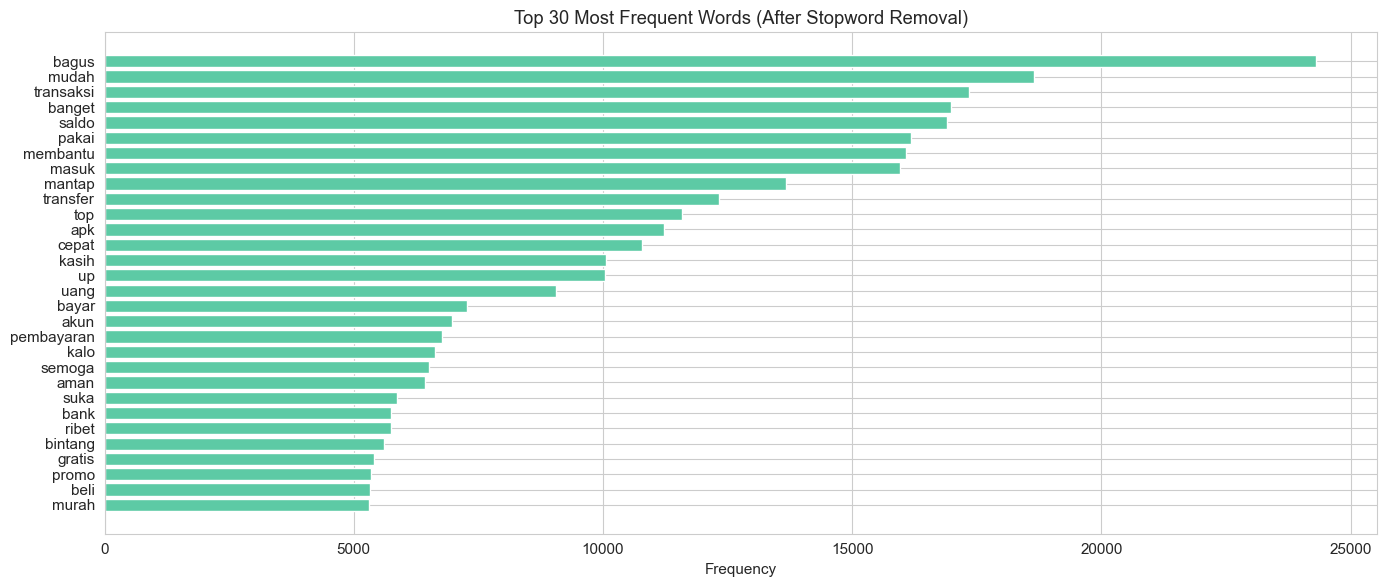

In [20]:
# ── Visualisasi Top 30 ──
top30 = word_freq.most_common(30)
w30, c30 = zip(*top30)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(30), c30, color='#5DCAA5', edgecolor='white')
ax.set_yticks(range(30))
ax.set_yticklabels(w30)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words (After Stopword Removal)')
plt.tight_layout()
plt.show()

### 13.1 Feedback Loop: Tambah Noise Words ke Stopwords

Setelah melihat output TOP 50 / 100 di atas, isi `found_noise_words` dengan kata-kata
yang jelas **tidak membawa sinyal sentimen** untuk review GoPay.

> **Jangan hapus** kata yang memiliki muatan emosi meskipun frekuensinya tinggi
> (contoh: `bagus`, `lambat`, `kecewa`, `error` — ini justru kunci sentimen).

In [21]:
# Data-driven dari hasil TOP 100 frequency analysis
# Hanya kata yang TIDAK membawa sinyal sentimen untuk GoPay reviews

found_noise_words = {
    # Singkatan & simbol
    'rp',          # simbol rupiah — konteks numerik, sudah dihapus angkanya
    'tf',          # singkatan 'transfer' yang tidak baku
    'wdp',         # singkatan tidak jelas
    'cs',          # 'customer service' — terlalu umum
    'min',         # panggilan 'admin/mimin' — tidak informatif

    # Varian yang sudah dicakup stopwords/slang
    'terimakasih', # varian dari 'terima kasih'
    'aplikasinya', # varian dari 'aplikasi' (sudah di domain_sw)
    'gue',         # varian 'saya' (harusnya sudah di-normalize slang)
    'gua',         # varian 'saya'
    'ku',          # sufiks/kata ganti
    'hp',          # 'handphone' — konteks netral, tidak spesifik sentimen

    # Filler & partikel
    'pokoknya',    # filler tanpa kandungan sentimen
    'mulu',        # filler ('terus-menerus') — ambigu
    'oke',         # respon netral

    # Kata konteks netral untuk GoPay
    'apk',         # varian 'aplikasi'
    'up',          # 'top up' terpotong — tidak berdiri sendiri
    'kali',        # penanda frekuensi netral ('beberapa kali')
    'bintang',     # artefak dari sistem rating, bukan opini
}

if found_noise_words:
    all_stopwords.update(found_noise_words)
    df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)
    print(f'Added {len(found_noise_words)} noise words to stopwords.')
    print(f'Total stopwords: {len(all_stopwords)}')
else:
    print('No new words added.')

Added 18 noise words to stopwords.
Total stopwords: 805


## 14. Lemmatization

Using **`nlp-id`** by Kumparan — a production Indonesian NLP library. The `Lemmatizer`
class is trained on Indonesian corpus data and handles prefix/suffix morphology
(me-, di-, ber-, ter-, ke-an, pe-an, etc.) without any manual dictionary.

> PyPI: https://pypi.org/project/nlp-id/  
> Unlike `spacy id_core_news_sm` (which is incompatible with spaCy v3.8+),
> `nlp-id` works as a standalone pip install with no model download required.

In [22]:
# Initialize nlp-id Lemmatizer
lemmatizer = Lemmatizer()

# Quick sanity check
test_words = ['menggunakan', 'pembayaran', 'bermasalah', 'membantu', 'pelayanan']
print('Lemmatization sanity check:')
for w in test_words:
    print(f'  {w:<20} -> {lemmatizer.lemmatize(w)}')

Lemmatization sanity check:
  menggunakan          -> guna
  pembayaran           -> bayar
  bermasalah           -> masalah
  membantu             -> bantu
  pelayanan            -> layan


In [23]:
def lemmatize_tokens(tokens):
    # nlp-id lemmatize() works per sentence string; we pass joined tokens
    if not tokens:
        return tokens
    result = lemmatizer.lemmatize(' '.join(tokens))
    return result.split()

df['tokens_lemma'] = df['tokens_no_sw'].apply(lemmatize_tokens)

# Count changed tokens
orig_flat  = [t for tl in df['tokens_no_sw'] for t in tl]
lemma_flat = [t for tl in df['tokens_lemma'] for t in tl]
changed = sum(a != b for a, b in zip(orig_flat, lemma_flat))
print(f'Tokens lemmatized: {changed:,}')
df[['tokens_no_sw', 'tokens_lemma']].head(5)

Tokens lemmatized: 1,110,940


,tokens_no_sw,tokens_lemma
0,"[pakai, kayak, top, brimo, ket, sukses, akun, ...","[pakai, kayak, top, brimo, ket, sukses, akun, ..."
1,[busuk],[busuk]
2,[bonus],[bonus]
3,"[good, kasih, promonya]","[good, kasih, promonya]"
4,"[terbaik, mendukung, bwnget]","[baik, dukung, bwnget]"


## 15. Stemming (PySastrawi)

Applied **after** lemmatization. Uses the Enhanced Confix Stripping (ECS) algorithm
— the standard stemmer for Bahasa Indonesia.

In [24]:
stemmer = StemmerFactory().create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_lemma'].apply(stem_tokens)
print('Stemming done.')
df[['tokens_lemma', 'tokens_stemmed']].head(5)

Stemming done.


,tokens_lemma,tokens_stemmed
0,"[pakai, kayak, top, brimo, ket, sukses, akun, ...","[pakai, kayak, top, brimo, ket, sukses, akun, ..."
1,[busuk],[busuk]
2,[bonus],[bonus]
3,"[good, kasih, promonya]","[good, kasih, promonya]"
4,"[baik, dukung, bwnget]","[baik, dukung, bwnget]"


## 16. Rare Words Removal

Remove words with corpus frequency ≤ threshold. These are typically typos that survived
earlier steps, unique brand names, or single-occurrence noise.

Threshold = **2** is standard in NLP review corpus literature (hapax legomena + near-hapax).

In [25]:
all_stemmed = [t for tl in df['tokens_stemmed'] for t in tl]
stemmed_freq = Counter(all_stemmed)

RARE_THRESHOLD = 2
rare_words = {w for w, f in stemmed_freq.items() if f <= RARE_THRESHOLD}

print(f'Unique words    : {len(stemmed_freq):,}')
print(f'Rare (freq<={RARE_THRESHOLD})  : {len(rare_words):,} '
      f'({len(rare_words)/len(stemmed_freq)*100:.1f}% of vocab)')
print(f'Sample rare     : {list(rare_words)[:15]}')

df['tokens_no_rare'] = df['tokens_stemmed'].apply(
    lambda t: [w for w in t if w not in rare_words]
)
before = df['tokens_stemmed'].apply(len).sum()
after  = df['tokens_no_rare'].apply(len).sum()
print(f'\nTokens removed: {before-after:,}')

Unique words    : 68,549
Rare (freq<=2)  : 56,200 (82.0% of vocab)
Sample rare     : ['ramadhaan', 'vz', 'blokri', 'disingkron', 'hilangtersedot', 'diugrep', 'lainnnya', 'tokaidolah', 'malahangimana', 'sihsoalnya', 'accountmantap', 'rekeningal', 'sesuaihapus', 'apaaan', 'tpiii']

Tokens removed: 63,291


## 17. Common Words Removal (Document Frequency)

Uses **document frequency (DF)** — not raw count — to identify overly common words.
A word appearing in >50% of documents carries near-zero discriminative power for TF-IDF.

This threshold is aligned with the IDF formula: words with DF > 50% get IDF ≈ log(2) ≈ 0.69,
effectively down-weighting them anyway. Removing them here keeps the vocabulary clean.

In [26]:
DF_THRESHOLD = 0.50  # words in >50% of all reviews

doc_freq = Counter()
for tokens in df['tokens_no_rare']:
    doc_freq.update(set(tokens))  # count once per document

n_docs = len(df)
common_words = {w for w, c in doc_freq.items() if c / n_docs > DF_THRESHOLD}

print(f'Total docs       : {n_docs:,}')
print(f'DF threshold     : >{DF_THRESHOLD*100:.0f}%')
print(f'Common words found: {len(common_words)}')
if common_words:
    for w in sorted(common_words, key=lambda x: doc_freq[x], reverse=True):
        print(f'  {w:<20} DF={doc_freq[w]:,} ({doc_freq[w]/n_docs*100:.1f}%)')

df['tokens_final'] = df['tokens_no_rare'].apply(
    lambda t: [w for w in t if w not in common_words]
)
before = df['tokens_no_rare'].apply(len).sum()
after  = df['tokens_final'].apply(len).sum()
print(f'\nTokens removed: {before-after:,}')

Total docs       : 218,644
DF threshold     : >50%
Common words found: 0

Tokens removed: 0


## 18. Reconstruct Text & Validation

In [27]:
df['final_text'] = df['tokens_final'].apply(lambda t: ' '.join(t))

empty = (df['final_text'].str.strip() == '').sum()
print(f'Empty rows after full pipeline: {empty:,}')
df = df[df['final_text'].str.strip() != '']
print(f'Final row count: {len(df):,}')

Empty rows after full pipeline: 9,333
Final row count: 209,311


In [28]:
# Before vs After
print('Sample comparison (Original -> Final)\n')
for _, row in df[['content','final_text']].sample(5, random_state=42).iterrows():
    print(f'  ORIGINAL : {row["content"][:85]}')
    print(f'  FINAL    : {row["final_text"][:85]}')
    print()

Sample comparison (Original -> Final)

  ORIGINAL : mantap pokoknya 😍😍😍😍😍🫰🫰🫰🫰
  FINAL    : mantap

  ORIGINAL : knp banyak iklan gopay ke sayaa
  FINAL    : iklan

  ORIGINAL : Ada nya gopay memudahkan pembayarannya. Untuk memesan makanan.
  FINAL    : mudah bayar pesan makan

  ORIGINAL : aplikasi simpel dan sangat membantu
  FINAL    : simpel bantu

  ORIGINAL : Aplikasi yang mudah...bantuan pun cepat ditanggapi...semua permasalahan selesai sesua
  FINAL    : cepat masalah selesai sesuai kasih uang bantu



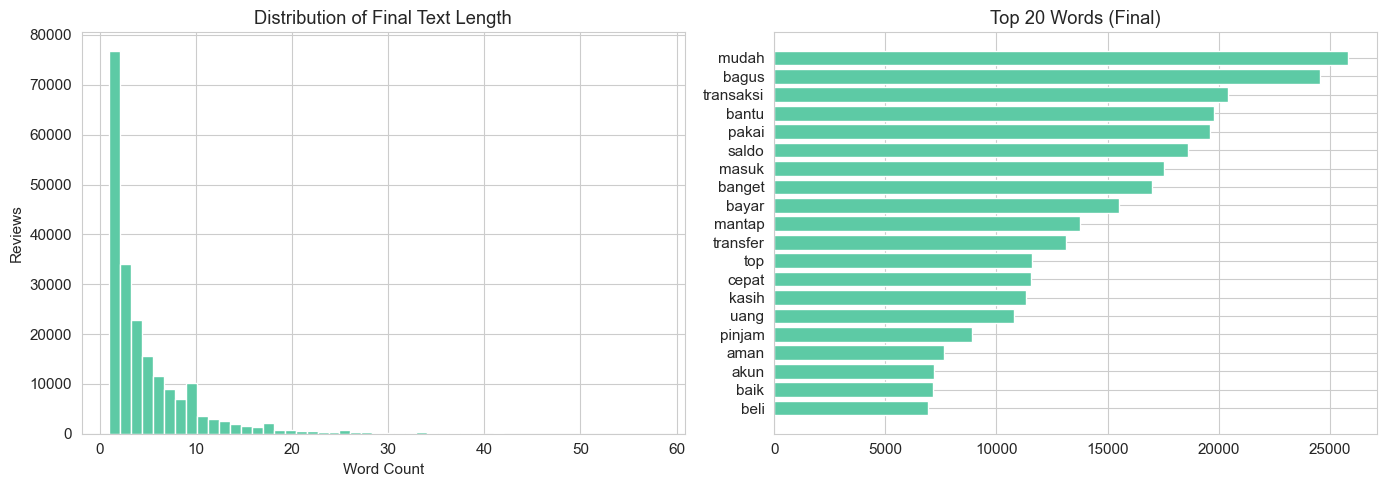

In [29]:
df['final_word_count'] = df['final_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['final_word_count'], bins=50, color='#5DCAA5', edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Reviews')
axes[0].set_title('Distribution of Final Text Length')

all_final = ' '.join(df['final_text']).split()
fw, fc = zip(*Counter(all_final).most_common(20))
axes[1].barh(range(20), fc, color='#5DCAA5', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(fw)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Words (Final)')

plt.tight_layout()
plt.show()

## 19. Save `cleandata.csv`

In [30]:
cols_to_save = [
    'content', 'score', 'at', 'thumbsUpCount',
    'replyContent', 'sentiment', 'final_text', 'tokens_final'
]
df_clean = df[cols_to_save].copy()

df_clean.to_csv('gopay_reviews_cleandata.csv', index=False)
print(f'Saved: gopay_reviews_.csv')
print(f'Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
df_clean.head(5)

Saved: gopay_reviews_.csv
Shape: 209,311 rows x 8 columns


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,pakai kayak top brimo ket sukses akun saldo ma...,"[pakai, kayak, top, brimo, ket, sukses, akun, ..."
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,[busuk]
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,bonus,[bonus]
3,"good, kasih donk promonya",5,2026-02-28 15:10:00,0,NaN,positive,good kasih promonya,"[good, kasih, promonya]"
4,terbaik mendukung bwnget,5,2026-02-28 15:08:01,0,NaN,positive,baik dukung,"[baik, dukung]"


## 20. Preprocessing Summary

| Step | Task | Tool | Why This Tool |
|------|------|------|---------------|
| 5 | Case folding | `.str.lower()` | — |
| 6 | Slang normalization | **kamus-alay** (5,700 entries) | Published research corpus, no manual entries |
| 7 | Text cleaning | `re`, `emoji` | — |
| 8 | Spelling correction | **`autocorrect` lang=id** | Statistical model from Indonesian corpus |
| 9 | Tokenization | **NLTK** `word_tokenize` | — |
| 10 | Stopword removal | **NLTK** Indo + Sastrawi + domain | 3-layer, research-backed |
| 11 | Frequent words (n=50/100/1000) | `Counter` | Data-driven feedback loop |
| 12 | Lemmatization | **`nlp-id`** (Kumparan) | Trained Indonesian model, pip-installable |
| 13 | Stemming | **PySastrawi** ECS | Standard Indonesian stemmer |
| 14 | Rare words removal | freq ≤ 2 | Corpus-relative threshold |
| 15 | Common words removal | doc freq > 50% | Aligned with TF-IDF IDF logic |

### Library rationale

| Task | Rejected | Used | Reason |
|------|---------|------|--------|
| Slang | Hand-written dict | `kamus-alay` | 50× more coverage, peer-reviewed source |
| Lemmatization | `spacy id_core_news_sm` | `nlp-id` | spaCy model incompatible with v3.8+; `nlp-id` works out-of-the-box |
| Spelling | Manual corrections | `autocorrect` | Statistical model, no maintenance needed |
| New stopwords | Pre-decided list | Frequency analysis output | Data-driven, reproducible |